In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import comb

In [2]:
# ============================================================
# -- Switch  (only change this one line) ---------------------
# ============================================================

CASE = 2   # 1 = Quadratic 2D,  2 = Quartic 3D


# ============================================================
# -- CASE Data  (do not change) --------------------------
# ============================================================

CASE_DATA = {
    1: dict(
        points = np.array([
            [1, 1],   # P0
            [3, 3],   # P1
            [5, 1],   # P2
        ]),
        u_highlight = [0.00, 0.25, 0.50, 0.75, 1.00],
        u_dc        = 0.50,
        output      = '31-bezier-quadratic-2d.png',
    ),
    2: dict(
        points = np.array([
            [0, 0, 1],   # P0
            [0, 4, 1],   # P1
            [4, 0, 1],   # P2
            [4, 4, 1],   # P3
            [5, 4, 1],   # P4
        ]),
        u_highlight = [0.00, 0.25, 0.50, 0.75, 1.00],
        u_dc        = 0.50,
        output      = '31-bezier-quartic-3d.png',
    ),
}

In [3]:
# ============================================================
# -- Bezier Computation  (generic — do not change) -----------
# ============================================================

class BezierCurve:
    """
    Generic Bezier curve of any degree, 2D or 3D.

    Degree is inferred automatically:
      n control points → degree n-1.

    The spatial dimension (2D or 3D) is inferred from
    the width of the points array (2 or 3 columns).
    """

    def __init__(self, points: np.ndarray):
        self.points = points           # shape (n, dim)
        self.n      = len(points)      # number of control pts
        self.degree = self.n - 1      # polynomial degree
        self.dim    = points.shape[1]  # 2 or 3

    # -- Core math -------------------------------------------

    def _bernstein(self, i: int, u: float) -> float:
        """
        Bernstein basis polynomial B(n, i, u).

        B(n,i,u) = C(n,i) * u^i * (1-u)^(n-i)
        """
        n = self.degree
        return comb(n, i) * (u ** i) * ((1 - u) ** (n - i))

    def point(self, u: float) -> np.ndarray:
        """
        Evaluate curve point at parameter u.

        P(u) = sum_{i=0}^{n} B(n,i,u) * P_i
        """
        return sum(
            self._bernstein(i, u) * self.points[i]
            for i in range(self.n)
        )

    def curve(self, n_pts: int = 300) -> np.ndarray:
        """Return dense array of curve points for plotting."""
        return np.array([
            self.point(u) for u in np.linspace(0, 1, n_pts)
        ])

    def highlight_points(self, u_list: list) -> np.ndarray:
        """Return curve points for a given list of u values."""
        return np.array([self.point(u) for u in u_list])

    # -- De Casteljau ----------------------------------------

    def de_casteljau(self, u: float) -> list:
        """
        Compute all De Casteljau reduction levels at u.

        Returns list of arrays, one per level:
          level[0]    = original control points  (n pts)
          level[1]    = first reduction          (n-1 pts)
          ...
          level[n]    = final curve point        (1 pt)
        """
        levels  = [self.points.copy()]
        current = self.points.copy()
        while len(current) > 1:
            current = np.array([
                (1 - u) * current[j] + u * current[j + 1]
                for j in range(len(current) - 1)
            ])
            levels.append(current)
        return levels

    # -- Derived labels --------------------------------------

    @property
    def degree_name(self) -> str:
        names = {2: 'Quadratic', 3: 'Cubic',
                 4: 'Quartic',   5: 'Quintic'}
        return names.get(self.degree, f'Degree-{self.degree}')

    @property
    def dim_name(self) -> str:
        return '3D' if self.dim == 3 else '2D'

In [4]:
# ============================================================
# -- Plot  (generic — do not change) -------------------------
# ============================================================

class BezierPlot:
    """
    Plot a Bezier curve in 2D or 3D automatically.

    Detects dimensionality from bezier.dim and sets up
    the correct axes (standard or 3D projection).
    All drawing logic is shared — only axis calls differ.
    """

    COLOR_CURVE   = '#1565C0'
    COLOR_POLYGON = '#E53935'
    COLOR_CTRL    = '#E53935'
    COLOR_POINT   = '#1B5E20'
    COLOR_LABEL   = '#4A148C'
    COLOR_DC = [
        '#F57F17',   # level 1 — amber
        '#EC407A',   # level 2 — pink
        '#7B1FA2',   # level 3 — violet
        '#1B5E20',   # level 4 — green (final point)
    ]

    def __init__(
        self,
        bezier:      BezierCurve,
        u_highlight: list,
        u_dc:        float = 0.5,
    ):
        self.bezier      = bezier
        self.u_highlight = u_highlight
        self.u_dc        = u_dc
        self.is_3d       = (bezier.dim == 3)
        self.fig, self.ax = self._init_figure()

    # -- Figure setup ----------------------------------------

    def _init_figure(self):
        sns.set_theme(style='whitegrid')
        if self.is_3d:
            fig = plt.figure(figsize=(10, 7))
            ax  = fig.add_subplot(111, projection='3d')
        else:
            fig, ax = plt.subplots(figsize=(9, 7))
        return fig, ax

    # -- Unified plot helpers (2D / 3D) ----------------------

    def _coords(self, pts: np.ndarray) -> tuple:
        """
        Unpack point array into coordinate tuples.
        Returns (x, y) for 2D or (x, y, z) for 3D.
        """
        if self.is_3d:
            return pts[:, 0], pts[:, 1], pts[:, 2]
        return pts[:, 0], pts[:, 1]

    def _plot_line(self, pts, **kwargs):
        """Draw a line through pts in either 2D or 3D."""
        self.ax.plot(*self._coords(pts), **kwargs)

    def _scatter_pts(self, pts, **kwargs):
        """Scatter-plot pts in either 2D or 3D."""
        if self.is_3d:
            xs, ys, zs = self._coords(pts)
            self.ax.scatter(xs, ys, zs, **kwargs)
        else:
            xs, ys = self._coords(pts)
            self.ax.scatter(xs, ys, **kwargs)

    def _annotate(self, pt, text, dx, dy, dz, color):
        """Place a text label near a point in 2D or 3D."""
        if self.is_3d:
            self.ax.text(
                pt[0] + dx, pt[1] + dy, pt[2] + dz,
                text, fontsize=8, color=color,
                fontweight='bold',
            )
        else:
            self.ax.annotate(
                text,
                xy     = (pt[0], pt[1]),
                xytext = (pt[0] + dx, pt[1] + dy),
                fontsize   = 8.5,
                color      = color,
                fontweight = 'bold',
            )

    # -- Drawing methods -------------------------------------

    def _draw_curve(self):
        """Draw the smooth Bezier curve."""
        pts = self.bezier.curve()
        self._plot_line(
            pts,
            color     = self.COLOR_CURVE,
            linewidth = 2.5,
            label     = 'Bezier Curve',
            zorder    = 3,
        )

    def _draw_control_polygon(self):
        """Draw dashed polygon connecting all control points."""
        self._plot_line(
            self.bezier.points,
            color      = self.COLOR_POLYGON,
            linestyle  = '--',
            linewidth  = 1.5,
            marker     = 'o',
            markersize = 8,
            label      = 'Control Polygon',
            zorder     = 4,
        )

    def _label_control_points(self):
        """Label each control point as P0, P1, ..."""
        for i, pt in enumerate(self.bezier.points):
            coords = ', '.join(f'{v:.4g}' for v in pt)
            name   = f'P{i}({coords})'
            # Alternate above/below to reduce overlap
            dy = 0.15 if i % 2 == 0 else -0.28
            self._annotate(
                pt, name,
                dx=0.10, dy=dy, dz=0.05,
                color=self.COLOR_CTRL,
            )

    def _draw_highlight_points(self):
        """Draw and annotate curve points at u_highlight."""
        pts = self.bezier.highlight_points(self.u_highlight)
        self._scatter_pts(
            pts,
            color  = self.COLOR_POINT,
            s      = 60,
            zorder = 5,
            label  = 'Points at u',
        )
        for u, pt in zip(self.u_highlight, pts):
            coords = ', '.join(f'{v:.3g}' for v in pt)
            text   = f'u={u:.2f}\n({coords})'
            dx     = -0.55 if u == 1.0 else 0.08
            dy     = -0.28 if u in (0.0, 1.0) else 0.10
            if self.is_3d:
                self.ax.text(
                    pt[0] + 0.08, pt[1] + 0.08, pt[2] + 0.05,
                    f'u={u:.2f}',
                    fontsize = 7,
                    color    = self.COLOR_LABEL,
                )
            else:
                self.ax.annotate(
                    text,
                    xy     = (pt[0], pt[1]),
                    xytext = (pt[0] + dx, pt[1] + dy),
                    fontsize = 7.5,
                    color    = self.COLOR_LABEL,
                    bbox     = dict(
                        boxstyle = 'round,pad=0.2',
                        fc='white', alpha=0.65, ec='none',
                    ),
                )

    def _draw_de_casteljau(self):
        """
        Draw De Casteljau intermediate levels at u_dc.
        Works identically for 2D and 3D.
        """
        levels = self.bezier.de_casteljau(self.u_dc)

        # Levels 1 .. n-1 : intermediate lines + dots
        for lv in range(1, len(levels) - 1):
            pts = levels[lv]
            col = self.COLOR_DC[
                min(lv - 1, len(self.COLOR_DC) - 1)
            ]
            self._plot_line(
                pts,
                color      = col,
                linewidth  = 1.4,
                marker     = 'o',
                markersize = 6,
                zorder     = 6,
                label      = f'DC level {lv}',
            )

        # Final point — diamond marker
        final = levels[-1]
        col   = self.COLOR_DC[
            min(len(levels) - 2, len(self.COLOR_DC) - 1)
        ]
        self._scatter_pts(
            final,
            color  = col,
            marker = 'D',
            s      = 90,
            zorder = 7,
            label  = f'DC final  u={self.u_dc:.2f}',
        )

    def _add_equation_box(self):
        """Show Bernstein basis notation as a text box."""
        n     = self.bezier.degree
        terms = ' + '.join(
            f'B({n},{i})\u00b7P\u2080' if i == 0
            else f'B({n},{i})\u00b7P{i}'
            for i in range(self.bezier.n)
        )
        text = (
            f'P(u) = {terms}\n'
            f'B(n,i,u) = C(n,i)\u00b7u\u1d35\u00b7(1-u)^(n-i)'
        )
        # 3D axes don't support transAxes text — use figure
        if self.is_3d:
            self.fig.text(
                0.13, 0.92, text,
                fontsize   = 8,
                fontfamily = 'monospace',
                va         = 'top',
                bbox       = dict(
                    boxstyle  = 'round,pad=0.4',
                    facecolor = 'lightyellow',
                    alpha     = 0.85,
                ),
            )
        else:
            self.ax.text(
                0.02, 0.97, text,
                transform  = self.ax.transAxes,
                fontsize   = 8,
                fontfamily = 'monospace',
                va         = 'top',
                bbox       = dict(
                    boxstyle  = 'round,pad=0.4',
                    facecolor = 'lightyellow',
                    alpha     = 0.85,
                ),
            )

    def _set_decorations(self):
        """Title, axis labels, legend — adapted for 2D/3D."""
        title = (
            f'Bezier Curve: {self.bezier.degree_name} '
            f'({self.bezier.dim_name}, '
            f'{self.bezier.n} Control Points)'
        )
        self.ax.set_title(
            title, fontsize=13, fontweight='bold', pad=14
        )
        self.ax.set_xlabel('x', fontsize=11)
        self.ax.set_ylabel('y', fontsize=11)
        if self.is_3d:
            self.ax.set_zlabel('z', fontsize=11)
        self.ax.legend(fontsize=8, loc='lower right')

        # Auto limits for 2D only
        # (3D auto-scales from the data)
        if not self.is_3d:
            pts   = self.bezier.points
            curve = self.bezier.curve()
            all_x = np.concatenate([pts[:, 0], curve[:, 0]])
            all_y = np.concatenate([pts[:, 1], curve[:, 1]])
            m = 0.8
            self.ax.set_xlim(all_x.min()-m, all_x.max()+m)
            self.ax.set_ylim(all_y.min()-m, all_y.max()+m)

    # -- Main ------------------------------------------------

    def draw(self):
        """Compose all plot elements."""
        self._draw_curve()
        self._draw_control_polygon()
        self._label_control_points()
        self._draw_highlight_points()
        self._draw_de_casteljau()
        self._add_equation_box()
        self._set_decorations()

    def save(self, filename: str):
        self.fig.tight_layout()
        self.fig.savefig(filename, dpi=150)
        print(f'Saved: {filename}')

    def show(self):
        self.fig.tight_layout()
        plt.show()

In [5]:
# ============================================================
# -- Entry Point ---------------------------------------------
# ============================================================

def main() -> int:
    data   = CASE_DATA[CASE]
    bezier = BezierCurve(data['points'])
    plot   = BezierPlot(
        bezier,
        u_highlight = data['u_highlight'],
        u_dc        = data['u_dc'],
    )
    plot.draw()
    plot.save(data['output'])
    plot.show()
    return 0

Saved: 31-bezier-quartic-3d.png


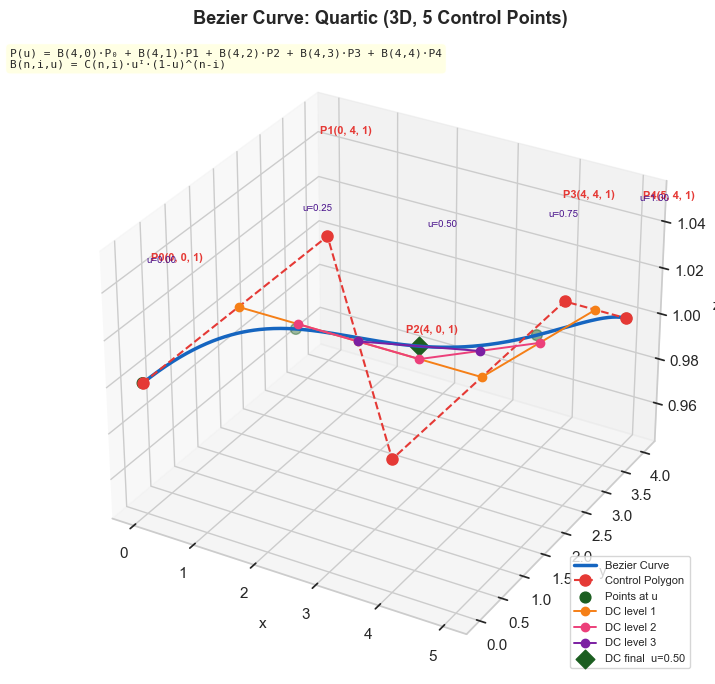

0

In [6]:
main()